In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [4]:
df.shape

(1470, 35)

In [5]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
# Attrition sütununu binary-yə çevirmək (Yes=1, No=0)
df['Attrition_Binary'] = df['Attrition'].map({'Yes': 1, 'No': 0})

In [8]:
# 2. Ümumi attrition rate-in hesablanması
total_employees = len(df)
total_attritions = df['Attrition_Binary'].sum()
overall_attrition_rate = (total_attritions / total_employees) * 100

In [9]:
print(f"Ümumi işçi sayı: {total_employees}")
print(f"Şirkəti tərk edənlər (Attrition): {total_attritions}")
print(f"Ümumi Attrition Rate: {overall_attrition_rate:.2f}%")

Ümumi işçi sayı: 1470
Şirkəti tərk edənlər (Attrition): 237
Ümumi Attrition Rate: 16.12%


In [10]:
kpi_data = []
for status, group in df.groupby('Attrition'):
    kpi_data.append({
        'Status': status,
        'Total Employees': len(group),
        'Total Attritions': group['Attrition_Binary'].sum() if status == 'Yes' else 0,
        'Share of Total (%)': round((len(group) / len(df)) * 100, 2),
        'Avg Monthly Income': round(group['MonthlyIncome'].mean(), 2),
        'Avg Years At Company': round(group['YearsAtCompany'].mean(), 2),
        'Avg Job Satisfaction': round(group['JobSatisfaction'].mean(), 2)
    })

kpi_df = pd.DataFrame(kpi_data)
display(kpi_df.style.background_gradient(subset=['Avg Monthly Income', 'Avg Job Satisfaction'], cmap='Blues'))

,Status,Total Employees,Total Attritions,Share of Total (%),Avg Monthly Income,Avg Years At Company,Avg Job Satisfaction
0,No,1233,0,83.880000,6832.740000,7.370000,2.780000
1,Yes,237,237,16.120000,4787.090000,5.130000,2.470000


In [11]:
# Tenure qruplarının yaradılması (0–2 yrs, 3–5 yrs, 6–10 yrs, 11+ yrs)
bins = [-1, 2, 5, 10, df['YearsAtCompany'].max()]
labels = ['0–2 yrs', '3–5 yrs', '6–10 yrs', '11+ yrs']
df['Tenure_Group'] = pd.cut(df['YearsAtCompany'], bins=bins, labels=labels)

# Tenure qrupları üzrə attrition rate hesablanması
tenure_attrition = df.groupby('Tenure_Group', observed=False)['Attrition_Binary'].agg(
    Total_Employees='count',
    Attritions='sum',
    Attrition_Rate=lambda x: round((x.sum() / len(x)) * 100, 2)
).reset_index()

display(tenure_attrition)

,Tenure_Group,Total_Employees,Attritions,Attrition_Rate
0,0–2 yrs,342,102,29.82
1,3–5 yrs,434,60,13.82
2,6–10 yrs,448,55,12.28
3,11+ yrs,246,20,8.13


In [12]:
# Income qruplarının yaradılması (Q1–Q4)
df['Income_Quartile'] = pd.qcut(df['MonthlyIncome'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])

# Income kvartilləri üzrə attrition rate hesablanması
income_attrition = df.groupby('Income_Quartile', observed=False)['Attrition_Binary'].agg(
    Total_Employees='count',
    Attritions='sum',
    Attrition_Rate=lambda x: round((x.sum() / len(x)) * 100, 2)
).reset_index()

display(income_attrition)

,Income_Quartile,Total_Employees,Attritions,Attrition_Rate
0,Q1,369,108,29.27
1,Q2,366,52,14.21
2,Q3,367,39,10.63
3,Q4,368,38,10.33


In [13]:
# Bonus - Cost of Attrition hesablanması (Replacement cost = 6 ay maaş × churned employee sayı)
total_churned = df['Attrition_Binary'].sum()
avg_monthly_income_churned = df[df['Attrition_Binary'] == 1]['MonthlyIncome'].mean()
total_attrition_cost = total_churned * (avg_monthly_income_churned * 6)

print(f"Cəmi ayrılan işçi sayı: {total_churned}")
print(f"İllik ümumi attrition xərci: ${total_attrition_cost:,.2f}")

Cəmi ayrılan işçi sayı: 237
İllik ümumi attrition xərci: $6,807,246.00


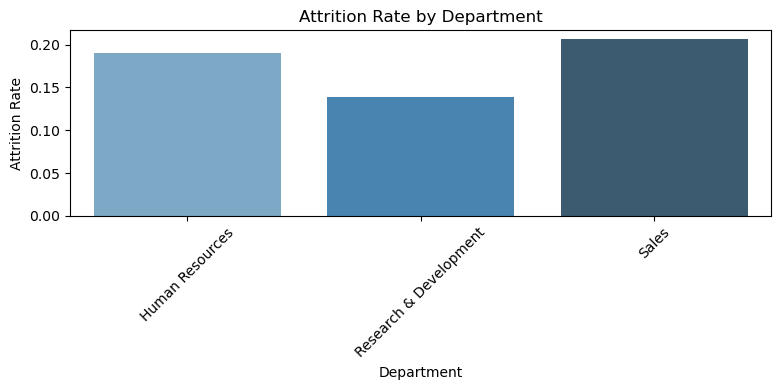

In [15]:
# Department üzrə Attrition Rate
plt.figure(figsize=(8, 4))
dept_attrition = df.groupby('Department')['Attrition_Binary'].mean().reset_index()
sns.barplot(data=dept_attrition, x='Department', y='Attrition_Binary', hue='Department', palette='Blues_d', legend=False)
plt.title('Attrition Rate by Department')
plt.ylabel('Attrition Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

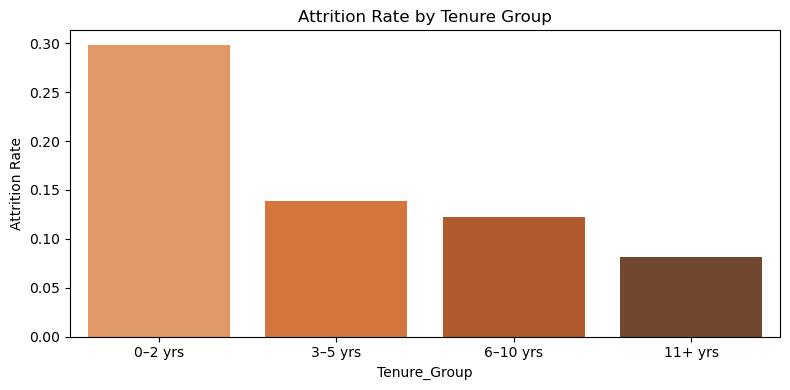

In [22]:
# Tenure Qrupu üzrə Attrition Rate
plt.figure(figsize=(8, 4))
tenure_attrition = df.groupby('Tenure_Group', observed=False)['Attrition_Binary'].mean().reset_index()
sns.barplot(data=tenure_attrition, x='Tenure_Group', y='Attrition_Binary', hue='Tenure_Group', palette='Oranges_d', legend=False)
plt.title('Attrition Rate by Tenure Group')
plt.ylabel('Attrition Rate')
plt.tight_layout()
plt.show()

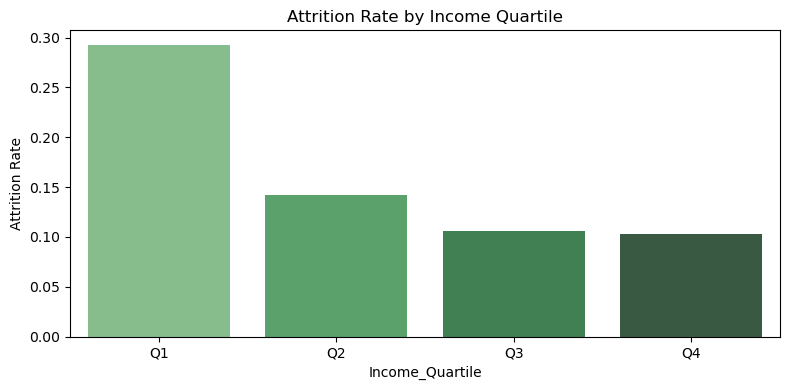

In [24]:
# Income Kvartili üzrə Attrition Rate
plt.figure(figsize=(8, 4))
income_attrition = df.groupby('Income_Quartile', observed=False)['Attrition_Binary'].mean().reset_index()
sns.barplot(data=income_attrition, x='Income_Quartile', y='Attrition_Binary', hue='Income_Quartile', palette='Greens_d', legend=False)
plt.title('Attrition Rate by Income Quartile')
plt.ylabel('Attrition Rate')
plt.tight_layout()
plt.show()

In [8]:
%run "w(8)teamtask1.ipynb"

Ümumi işçi sayı: 1470
Şirkəti tərk edənlər (Attrition): 237
Ümumi Attrition Rate: 16.12%


,Status,Total Employees,Total Attritions,Share of Total (%),Avg Monthly Income,Avg Years At Company,Avg Job Satisfaction
0,No,1233,0,83.880000,6832.740000,7.370000,2.780000
1,Yes,237,237,16.120000,4787.090000,5.130000,2.470000


,Tenure_Group,Total_Employees,Attritions,Attrition_Rate
0,0–2 yrs,342,102,29.82
1,3–5 yrs,434,60,13.82
2,6–10 yrs,448,55,12.28
3,11+ yrs,246,20,8.13


,Income_Quartile,Total_Employees,Attritions,Attrition_Rate
0,Q1,369,108,29.27
1,Q2,366,52,14.21
2,Q3,367,39,10.63
3,Q4,368,38,10.33


Cəmi ayrılan işçi sayı: 237
İllik ümumi attrition xərci: $6,807,246.00


In [10]:
# Department, JobRole, OverTime, MaritalStatus, Gender üzrə attrition rate
segment_cols = ['Department', 'JobRole', 'OverTime', 'MaritalStatus', 'Gender']

segment_results = {}
for col in segment_cols:
    rate = df.groupby(col)['Attrition_Binary'].agg(
        Total_Employees='count',
        Attritions='sum',
        Attrition_Rate=lambda x: round((x.sum() / len(x)) * 100, 2)
    ).sort_values('Attrition_Rate', ascending=False)
    segment_results[col] = rate
    print(f"--- {col} üzrə Attrition Rate ( % ) ---")
    display(rate)
    print()

--- Department üzrə Attrition Rate ( % ) ---


,Total_Employees,Attritions,Attrition_Rate
Department,,,
Sales,446,92,20.63
Human Resources,63,12,19.05
Research & Development,961,133,13.84



--- JobRole üzrə Attrition Rate ( % ) ---


,Total_Employees,Attritions,Attrition_Rate
JobRole,,,
Sales Representative,83,33,39.76
Laboratory Technician,259,62,23.94
Human Resources,52,12,23.08
Sales Executive,326,57,17.48
Research Scientist,292,47,16.10
Manufacturing Director,145,10,6.90
Healthcare Representative,131,9,6.87
Manager,102,5,4.90
Research Director,80,2,2.50



--- OverTime üzrə Attrition Rate ( % ) ---


,Total_Employees,Attritions,Attrition_Rate
OverTime,,,
Yes,416,127,30.53
No,1054,110,10.44



--- MaritalStatus üzrə Attrition Rate ( % ) ---


,Total_Employees,Attritions,Attrition_Rate
MaritalStatus,,,
Single,470,120,25.53
Married,673,84,12.48
Divorced,327,33,10.09



--- Gender üzrə Attrition Rate ( % ) ---


,Total_Employees,Attritions,Attrition_Rate
Gender,,,
Male,882,150,17.01
Female,588,87,14.80


In [ ]:
pivot_dept_jobsat = df.pivot_table(
    index='Department',
    columns='JobSatisfaction',
    values='Attrition_Binary',
    aggfunc='mean' ,
    observed=False
) * 100
pivot_dept_jobsat = pivot_dept_jobsat.round(2)
display(pivot_dept_jobsat.style.background_gradient(cmap='Reds', axis=None))

JobSatisfaction,1,2,3,4
Department,,,,
Human Resources,45.450000,10.000000,20.000000,11.760000
Research & Development,19.790000,13.790000,14.330000,9.490000
Sales,26.740000,23.260000,21.260000,14.970000


In [12]:
pivot_dept_wlb = df.pivot_table(
    index='Department',
    columns='WorkLifeBalance',
    values='Attrition_Binary',
    aggfunc='mean',
    observed=False
) * 100
pivot_dept_wlb = pivot_dept_wlb.round(2)
display(pivot_dept_wlb.style.background_gradient(cmap='Reds', axis=None))

WorkLifeBalance,1,2,3,4
Department,,,,
Human Resources,0.000000,28.570000,21.430000,10.000000
Research & Development,31.670000,13.620000,11.830000,15.380000
Sales,37.500000,23.530000,18.120000,23.080000


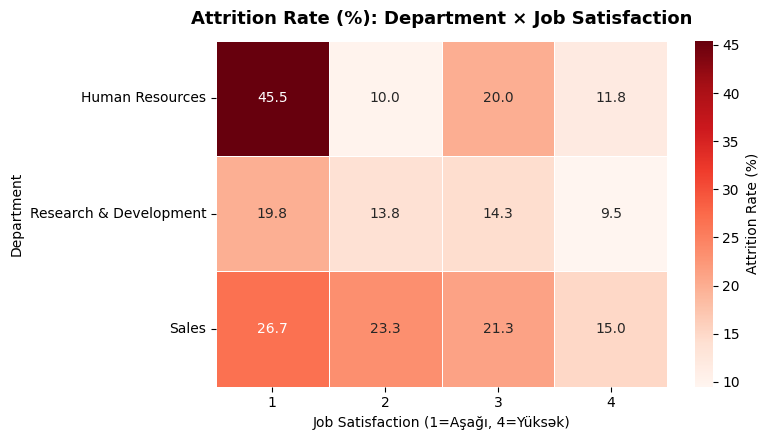

In [13]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.heatmap(
    pivot_dept_jobsat,
    annot=True,
    fmt=".1f",
    cmap="Reds",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Attrition Rate (%)"},
    ax=ax
)

ax.set_title("Attrition Rate (%): Department × Job Satisfaction", fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Job Satisfaction (1=Aşağı, 4=Yüksək)")
ax.set_ylabel("Department")

plt.tight_layout()
plt.savefig("dept_jobsat_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
numeric_df = df.select_dtypes(include='number').copy()
# Sabit sütunları çıxarırıq (məs. EmployeeCount, StandardHours) -      korrelyasiya hesablana bilməz
constant_cols = [c for c in numeric_df.columns if numeric_df[c].nunique() <= 1]
numeric_df = numeric_df.drop(columns=constant_cols)
corr_with_attrition = numeric_df.corr()['Attrition_Binary'].drop('Attrition_Binary')
top10_corr = (
    corr_with_attrition.reindex(corr_with_attrition.abs().sort_values(ascending=False).index)
    .head(10)
    .round(3)
)
top10_corr_df = top10_corr.rename('Correlation').to_frame()
top10_corr_df['Direction'] = top10_corr_df['Correlation'].apply(
    lambda v: 'Mənfi (qorunma)' if v < 0 else 'Müsbət (risk)'
)
print(f"Sabit sütun kimi çıxarıldı: {constant_cols}\n")
display(top10_corr_df)

Sabit sütun kimi çıxarıldı: ['EmployeeCount', 'StandardHours']



,Correlation,Direction
TotalWorkingYears,-0.171,Mənfi (qorunma)
JobLevel,-0.169,Mənfi (qorunma)
YearsInCurrentRole,-0.161,Mənfi (qorunma)
MonthlyIncome,-0.160,Mənfi (qorunma)
Age,-0.159,Mənfi (qorunma)
YearsWithCurrManager,-0.156,Mənfi (qorunma)
StockOptionLevel,-0.137,Mənfi (qorunma)
YearsAtCompany,-0.134,Mənfi (qorunma)
JobInvolvement,-0.130,Mənfi (qorunma)
JobSatisfaction,-0.103,Mənfi (qorunma)


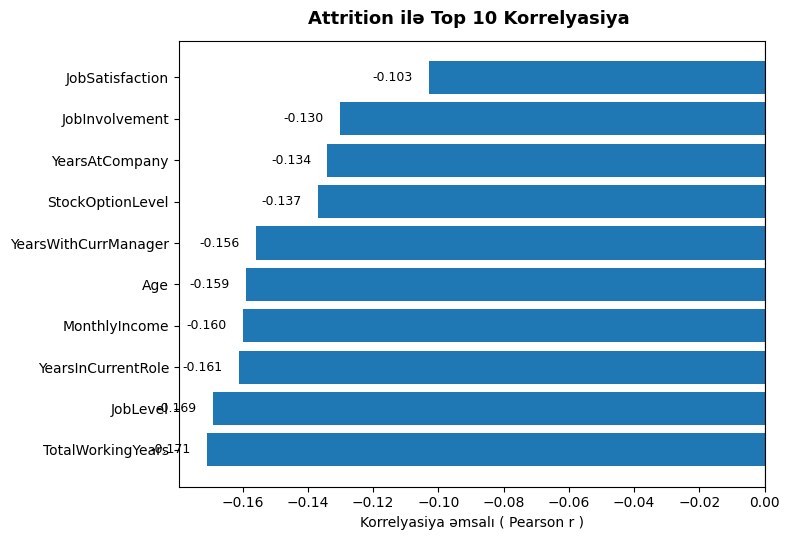

In [15]:
plot_data = top10_corr_df.sort_values('Correlation')
colors = plot_data['Correlation'].apply(lambda v: '#d62728' if v > 0 else '#1f77b4')
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(plot_data.index, plot_data['Correlation'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Attrition ilə Top 10 Korrelyasiya ', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Korrelyasiya əmsalı ( Pearson r )')
for i, v in enumerate(plot_data['Correlation']):
    offset = 0.005 if v >= 0 else -0.005
    ha = 'left' if v >= 0 else 'right'
    ax.text(v + offset, i, f"{v:.3f}", va='center', ha=ha, fontsize=9)  
plt.tight_layout()
plt.savefig("top10_correlation_bar.png", dpi=150, bbox_inches="tight")
plt.show()

In [16]:
def profile_rate(mask, name):
    n = mask.sum()
    rate = round(df.loc[mask, 'Attrition_Binary'].mean() * 100, 2) if n > 0 else None
    return {'Profile': name, 'n': int(n), 'Attrition_Rate(%)': rate}
candidate_profiles = [
    profile_rate((df.OverTime == 'Yes') & (df.MaritalStatus == 'Single'),
                 'OverTime=Yes & Single'),
    profile_rate((df.OverTime == 'Yes') & (df.JobSatisfaction == 1),
                 'OverTime=Yes & JobSatisfaction=1'),
    profile_rate((df.OverTime == 'Yes') & (df.Tenure_Group == '0–2 yrs'),
                 'OverTime=Yes & Tenure 0–2 yrs'),
    profile_rate((df.OverTime == 'Yes') & (df.Income_Quartile == 'Q1'),
                 'OverTime=Yes & Income Q1 (aşağı gəlir)'),
    profile_rate((df.MaritalStatus == 'Single') & (df.Tenure_Group == '0–2 yrs') & (df.OverTime == 'Yes'),
                 'Single & Tenure 0–2 yrs & OverTime=Yes'),
    profile_rate((df.JobRole == 'Sales Representative') & (df.OverTime == 'Yes'),
                 'Sales Representative & OverTime=Yes'),
    profile_rate((df.OverTime == 'Yes') & (df.WorkLifeBalance == 1),
                 'OverTime=Yes & WorkLifeBalance=1'),
    profile_rate((df.OverTime == 'Yes') & (df.JobSatisfaction == 1) & (df.Income_Quartile == 'Q1'),
                 'OverTime=Yes & JobSatisfaction=1 & Income Q1'),
]
risk_df = pd.DataFrame(candidate_profiles).sort_values('Attrition_Rate(%)', ascending=False)
print("Bütün yoxlanılan kombinasiyalar:")
display(risk_df)
top3_risk = risk_df[risk_df['n'] >= 20].head(3).reset_index(drop=True)
print("\n TOP 3 ƏN YÜKSƏK RİSKLİ PROFİL ( n>=20 ):")
display(top3_risk)

Bütün yoxlanılan kombinasiyalar:


,Profile,n,Attrition_Rate(%)
4,Single & Tenure 0–2 yrs & OverTime=Yes,42,69.05
5,Sales Representative & OverTime=Yes,24,66.67
7,OverTime=Yes & JobSatisfaction=1 & Income Q1,23,65.22
3,OverTime=Yes & Income Q1 (aşağı gəlir),106,58.49
2,OverTime=Yes & Tenure 0–2 yrs,104,50.96
0,OverTime=Yes & Single,131,49.62
6,OverTime=Yes & WorkLifeBalance=1,22,45.45
1,OverTime=Yes & JobSatisfaction=1,84,35.71



 TOP 3 ƏN YÜKSƏK RİSKLİ PROFİL ( n>=20 ):


,Profile,n,Attrition_Rate(%)
0,Single & Tenure 0–2 yrs & OverTime=Yes,42,69.05
1,Sales Representative & OverTime=Yes,24,66.67
2,OverTime=Yes & JobSatisfaction=1 & Income Q1,23,65.22


In [17]:
bonus_mask = (
    (df['OverTime'] == 'Yes')
    & (df['JobSatisfaction'] == 1)
    & (df['Income_Quartile'] == 'Q1')
)
bonus_n = bonus_mask.sum()
bonus_rate = round(df.loc[bonus_mask, 'Attrition_Binary'].mean() * 100, 2)
print(f"Bu kombinasiyaya uyğun işçi sayı: {bonus_n}")
print(f"Bu qrupun Attrition Rate-i: {bonus_rate}%")
print(f"(Müqayisə üçün: bütün şirkət üzrə orta Attrition Rate: {overall_attrition_rate:.2f}%)")

Bu kombinasiyaya uyğun işçi sayı: 23
Bu qrupun Attrition Rate-i: 65.22%
(Müqayisə üçün: bütün şirkət üzrə orta Attrition Rate: 16.12%)
